In [40]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from dotenv import load_dotenv
load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
DATASET_PATH="/data/Hermes"
CONFIG_DIRECTORY = os.getenv("CONFIG_DIRECTORY")

sys.path.append("../")
from mmwave_radar_processing.config_managers.cfgManager import ConfigManager
from cpsl_datasets.cpsl_ds import CpslDS
from mmwave_radar_processing.processors.range_angle_resp import RangeAngleProcessor
from mmwave_radar_processing.processors.range_doppler_resp import RangeDopplerProcessor
from mmwave_radar_processing.processors.range_angle_resp_dbs_enhanced import RangeAngleProcessorDBSEnhanced
from mmwave_radar_processing.processors.virtual_array_reformater import VirtualArrayReformatter
from mmwave_radar_processing.plotting.plotter_mmWave_data import PlotterMmWaveData
from mmwave_radar_processing.plotting.movies_mmWave_data import MovieGeneratorMmWaveData

In [41]:
cfg_manager = ConfigManager()

cfg_path = os.path.join(CONFIG_DIRECTORY,"1843_RadVel_10Hz_lr.cfg")
# cfg_path = os.path.join(CONFIG_DIRECTORY,"RadCloud_original.cfg")

cfg_manager.load_cfg(cfg_path)
cfg_manager.compute_radar_perforance(profile_idx=0)

cfg_manager.print_cfg_overview()

---- Radar Configuration Overview ----
Radar Performance
	range res: 0.14m
	range max: 12.29m
	vel res: 0.02m/s
	vel max: 1.22m/s
Profile Configuration:
	profile config: 
	{'profileId': 0, 'startFreq_GHz': 77.0, 'idleTime_us': 300.0, 'adcStartTime_us': 7.0, 'rampEndTime_us': 100.0, 'txOutPower': 0.0, 'txPhaseShifter': 0.0, 'freqSlope_MHz_us': 25.0, 'txStartTime_us': 1.0, 'adcSamples': 90, 'sampleRate_kSps': 2050, 'hpfCornerFreq1': 0, 'hpfCornerFreq2': 0, 'rxGain_dB': 30.0}
	Frame loops: 100
	Chirp period: 400.0 us
	Active frame time: 80.0 ms
	Frame period: 100.0
	Antenna Geometry: standard
	Operating Frequency: 77.0 GHz


In [42]:
dataset_name = "hermes_north_vicon_1"#"hermes_hudson_driveway","hermes_cpsl"
dataset_path = os.path.join(DATASET_PATH,dataset_name)
dataset = CpslDS(
    dataset_path=dataset_path,
    radar_adc_folder="front_radar_adc",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_orientation", #not implemented
    imu_full_folder="imu_data",
    vehicle_vel_folder="vehicle_vel",
    vehicle_odom_folder="vehicle_odom"
)

found 1065 radar ADC samples
found 1065 lidar samples
did not find camera samples
did not find imu (orientation) samples
did not find imu (full data) samples
found 1065 vehicle velocity samples
found 1065 vehicle odometry samples


In [43]:
#load the plotter
plotter = PlotterMmWaveData(config_manager=cfg_manager)

#initialize a range azimuth processor
range_az_processor = RangeAngleProcessor(
    config_manager=cfg_manager,
    num_angle_bins=64
)

#initialize a range_azimuth processor with doppler beam sharpening enhancement
range_az_processor_dbs_enhanced = RangeAngleProcessorDBSEnhanced(
    config_manager=cfg_manager,
    num_angle_bins_range_angle_response=64,
    num_angle_bins_dbs_enhanced_response=100,
    min_vel_dbs=cfg_manager.vel_res_m_s * 10
)
print("Range-Azimuth processor minimum velocity:{} m/s".format(range_az_processor_dbs_enhanced.min_vel_dbs))

#initialize the range doppler processor
range_doppler_processor = RangeDopplerProcessor(
    config_manager=cfg_manager
)

#load the ADC data reformatter
virtual_array_reformatter = VirtualArrayReformatter(config_manager=cfg_manager)

Range-Azimuth processor minimum velocity:0.25 m/s


[-0.02203145  0.34425047  0.02364595]


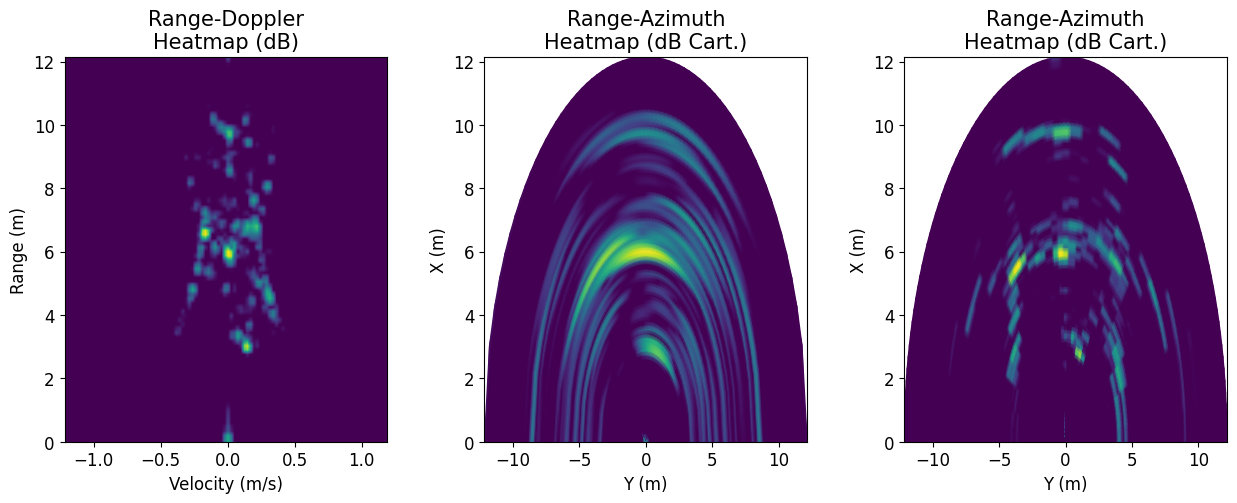

In [44]:
#for getting access to the adc cube
idx=194#194

#get velocity data
#get vel_data
vel_data = np.mean(dataset.get_vehicle_odom_data(idx)[:,8:11],axis=0)
#convert into ned
ned_vel_data = np.array([
    vel_data[0],
    vel_data[1],
    vel_data[2]
])

print(ned_vel_data)

#get the ADC cube
adc_cube = dataset.get_radar_adc_data(idx)

adc_cube = virtual_array_reformatter.process(adc_cube)
rng_az_resp = range_az_processor.process(adc_cube=adc_cube,chirp_idx=0)
rng_az_resp_dbs_enhanced = range_az_processor_dbs_enhanced.process(
    adc_cube=adc_cube,
    velocity_ned=ned_vel_data)
rng_dop_resp = range_doppler_processor.process(adc_cube=adc_cube,rx_idx=0)


#for generating a compilation of plots
fig,axs=plt.subplots(1,3, figsize=(15,5))
fig.subplots_adjust(wspace=0.3,hspace=0.30)

plotter.min_threshold_dB = 30
plotter.plot_range_doppler_resp(
    resp=rng_dop_resp,
    range_doppler_processor=range_doppler_processor,
    convert_to_dB=True,
    ax=axs[0],
    show=False
)

plotter.plot_range_az_resp_cart(
    resp=rng_az_resp,
    range_azimuth_processor=range_az_processor,
    convert_to_dB=True,
    ax=axs[1],
    show=False
)

plotter.plot_range_az_resp_cart(
    resp=rng_az_resp_dbs_enhanced,
    range_azimuth_processor=range_az_processor_dbs_enhanced,
    convert_to_dB=True,
    ax=axs[2],
    show=False
)
